In [1]:
# Cell 0: Complete Setup - Run this FIRST every time

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

# ── Project Paths ──────────────────────────────────────
BASE        = "D:/Projects/Harsh_Mini_Project/medical_xray_project"
IMG_DIR     = f"{BASE}/data/images"
MODELS      = f"{BASE}/models"
PLOTS       = f"{BASE}/outputs/plots"
RESULTS     = f"{BASE}/outputs/results"
DB_PATH     = f"{BASE}/database/xray_metadata.db"

# ── Valid Extensions ───────────────────────────────────
VALID_EXT   = ('.png', '.jpg', '.jpeg',
               '.PNG', '.JPG', '.JPEG')

# ── Hyperparameters ────────────────────────────────────
IMG_SIZE    = 224
BATCH_SIZE  = 16
RANDOM_SEED = 42
AUTOTUNE    = tf.data.AUTOTUNE

# ── Load CSV files ─────────────────────────────────────
train_df = pd.read_csv(f"{RESULTS}/train.csv",
                       encoding='utf-8')
val_df   = pd.read_csv(f"{RESULTS}/val.csv",
                       encoding='utf-8')
test_df  = pd.read_csv(f"{RESULTS}/test.csv",
                       encoding='utf-8')

print("=" * 50)
print("   CELL 0: SETUP COMPLETE")
print("=" * 50)
print(f"✅ TensorFlow  : {tf.__version__}")
print(f"✅ IMG_SIZE    : {IMG_SIZE}x{IMG_SIZE}")
print(f"✅ BATCH_SIZE  : {BATCH_SIZE}")
print()
print(f"✅ Train CSV   : {len(train_df):,} rows")
print(f"✅ Val CSV     : {len(val_df):,} rows")
print(f"✅ Test CSV    : {len(test_df):,} rows")
print()
print(f"✅ IMG_DIR     : {IMG_DIR}")
print("=" * 50)
print("✅ Cell 0 complete - Ready to proceed")

   CELL 0: SETUP COMPLETE
✅ TensorFlow  : 2.19.0
✅ IMG_SIZE    : 224x224
✅ BATCH_SIZE  : 16

✅ Train CSV   : 4,087 rows
✅ Val CSV     : 877 rows
✅ Test CSV    : 876 rows

✅ IMG_DIR     : D:/Projects/Harsh_Mini_Project/medical_xray_project/data/images
✅ Cell 0 complete - Ready to proceed


   CELL 1: IMAGE PREPROCESSING FUNCTION
✅ Function defined successfully

   Test image : train_PNEUMONIA_person898_bacteria_2823.jpeg
   Shape      : (224, 224, 3)
   Dtype      : float32
   Min pixel  : 0.0000
   Max pixel  : 1.0000
   Mean pixel : 0.5452



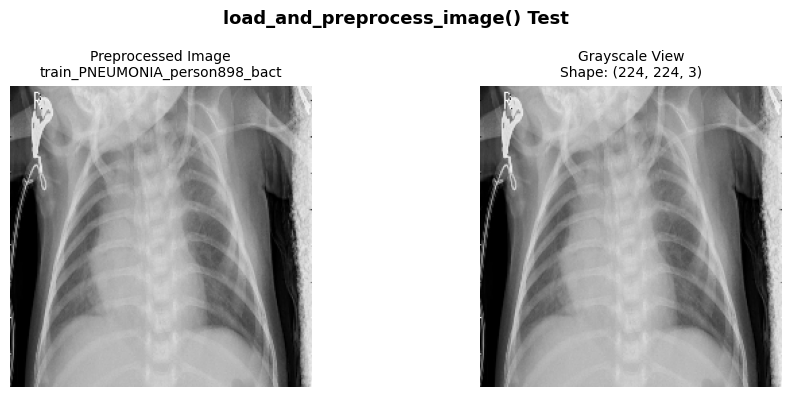

✅ Cell 1 complete


In [2]:
# Cell 1: Define image loading and preprocessing function

print("=" * 50)
print("   CELL 1: IMAGE PREPROCESSING FUNCTION")
print("=" * 50)

def load_and_preprocess_image(img_path):
    """
    Load a single image and preprocess it.
    Steps:
      1. Read image with OpenCV
      2. Convert BGR to RGB
      3. Resize to 224x224
      4. Normalize pixels to 0.0-1.0
    Returns: numpy array shape (224, 224, 3)
    """
    # Read image
    img = cv2.imread(img_path)
    
    if img is None:
        # Return blank image if file not found
        return np.zeros((IMG_SIZE, IMG_SIZE, 3),
                        dtype=np.float32)
    
    # Convert BGR to RGB (OpenCV loads as BGR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Resize to 224x224
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    
    # Normalize pixels from 0-255 to 0.0-1.0
    img = img.astype(np.float32) / 255.0
    
    return img

# ── Test the function ──────────────────────────────────
# Pick first image from train set
test_img_name = train_df['image_index'].iloc[0]
test_img_path = f"{IMG_DIR}/{test_img_name}"

test_img = load_and_preprocess_image(test_img_path)

print(f"✅ Function defined successfully")
print()
print(f"   Test image : {test_img_name}")
print(f"   Shape      : {test_img.shape}")
print(f"   Dtype      : {test_img.dtype}")
print(f"   Min pixel  : {test_img.min():.4f}")
print(f"   Max pixel  : {test_img.max():.4f}")
print(f"   Mean pixel : {test_img.mean():.4f}")
print()

# Display test image
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(test_img)
axes[0].set_title(f"Preprocessed Image\n{test_img_name[:30]}",
                  fontsize=10)
axes[0].axis('off')

axes[1].imshow(test_img, cmap='gray')
axes[1].set_title(f"Grayscale View\nShape: {test_img.shape}",
                  fontsize=10)
axes[1].axis('off')

plt.suptitle('load_and_preprocess_image() Test',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("=" * 50)
print("✅ Cell 1 complete")

   CELL 2: AUGMENTATION FUNCTION
   ⚠️  NO random_crop - causes TypeError in TF 2.19



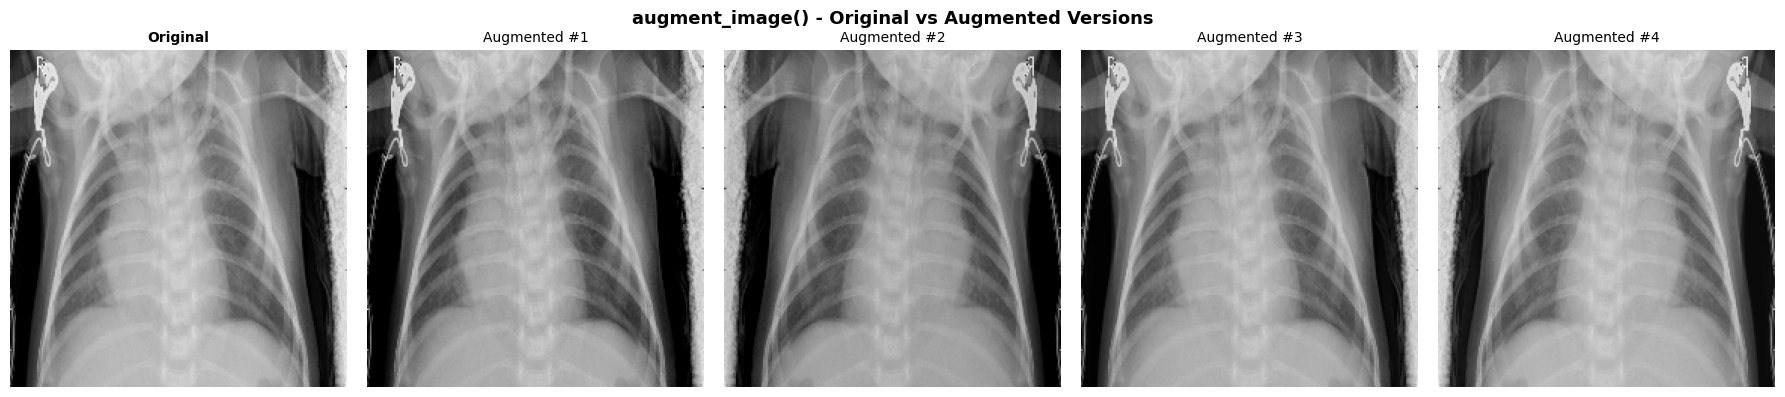

✅ Augmentation function defined
✅ Augmentations applied:
   • random_flip_left_right ✅
   • random_brightness (0.1) ✅
   • random_contrast (0.9-1.1) ✅
   • clip_by_value (0.0-1.0) ✅
   • random_crop ❌ (skipped - TF 2.19 bug)
✅ Cell 2 complete


In [3]:
# Cell 2: Define augmentation function for training images

print("=" * 50)
print("   CELL 2: AUGMENTATION FUNCTION")
print("=" * 50)
print("   ⚠️  NO random_crop - causes TypeError in TF 2.19")
print()

@tf.function
def augment_image(image, label):
    """
    Apply random augmentations to training images only.
    Augmentations used:
      1. Random horizontal flip
      2. Random brightness adjustment
      3. Random contrast adjustment
      4. Clip values to stay in 0.0-1.0 range
    
    NOT used (causes TypeError in TF 2.19.0):
      - random_crop
    """
    # 1. Random horizontal flip
    image = tf.image.random_flip_left_right(image)
    
    # 2. Random brightness (max change = 10%)
    image = tf.image.random_brightness(
        image, max_delta=0.1)
    
    # 3. Random contrast (factor between 0.9 and 1.1)
    image = tf.image.random_contrast(
        image, lower=0.9, upper=1.1)
    
    # 4. Clip pixel values to valid range
    image = tf.clip_by_value(image, 0.0, 1.0)
    
    return image, label

# ── Test augmentation ──────────────────────────────────
# Load one test image
test_img_name = train_df['image_index'].iloc[0]
test_img_path = f"{IMG_DIR}/{test_img_name}"
test_img      = load_and_preprocess_image(test_img_path)

# Convert to tensor for testing
img_tensor   = tf.constant(test_img)
label_tensor = tf.constant(1)

# Apply augmentation 4 times
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

# Original
axes[0].imshow(test_img)
axes[0].set_title('Original', fontsize=10,
                  fontweight='bold')
axes[0].axis('off')

# 4 augmented versions
for i in range(1, 5):
    aug_img, _ = augment_image(img_tensor, label_tensor)
    axes[i].imshow(aug_img.numpy())
    axes[i].set_title(f'Augmented #{i}',
                      fontsize=10)
    axes[i].axis('off')

plt.suptitle('augment_image() - Original vs Augmented Versions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"✅ Augmentation function defined")
print(f"✅ Augmentations applied:")
print(f"   • random_flip_left_right ✅")
print(f"   • random_brightness (0.1) ✅")
print(f"   • random_contrast (0.9-1.1) ✅")
print(f"   • clip_by_value (0.0-1.0) ✅")
print(f"   • random_crop ❌ (skipped - TF 2.19 bug)")
print("=" * 50)
print("✅ Cell 2 complete")

In [4]:
# Cell 3: Define create_dataset() function using tf.data

print("=" * 50)
print("   CELL 3: CREATE DATASET FUNCTION")
print("=" * 50)

def load_image_tf(img_path, label):
    """
    Load and preprocess a single image using TensorFlow.
    Uses decode_image (not decode_png) for JPEG support.
    """
    # Read raw bytes from file
    img = tf.io.read_file(img_path)
    
    # Decode image - works for JPEG, PNG, GIF, BMP
    # expand_animations=False needed for GIF handling
    img = tf.image.decode_image(
        img,
        channels          = 3,
        expand_animations = False
    )
    
    # Resize to 224x224
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    
    # Normalize to 0.0-1.0
    img = tf.cast(img, tf.float32) / 255.0
    
    return img, label


def create_dataset(dataframe, is_training=False):
    """
    Create a tf.data.Dataset from a DataFrame.
    
    Args:
        dataframe   : pandas DataFrame with image_index
                      and label columns
        is_training : if True, apply augmentation
    
    Returns:
        Batched and prefetched tf.data.Dataset
    """
    # Build full image paths
    img_paths = [f"{IMG_DIR}/{fname}"
                 for fname in dataframe['image_index']]
    labels    = dataframe['label'].tolist()
    
    # Create dataset from paths and labels
    dataset = tf.data.Dataset.from_tensor_slices(
        (img_paths, labels)
    )
    
    # Load and preprocess images
    dataset = dataset.map(
        load_image_tf,
        num_parallel_calls = AUTOTUNE
    )
    
    # Apply augmentation only for training
    if is_training:
        dataset = dataset.map(
            augment_image,
            num_parallel_calls = AUTOTUNE
        )
        # Shuffle training data
        dataset = dataset.shuffle(
            buffer_size  = 1000,
            seed         = RANDOM_SEED,
            reshuffle_each_iteration = True
        )
    
    # Batch and prefetch
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)
    
    return dataset

print(f"✅ load_image_tf()  defined")
print(f"   • Uses decode_image (JPEG safe) ✅")
print(f"   • Resizes to {IMG_SIZE}x{IMG_SIZE} ✅")
print(f"   • Normalizes to 0.0-1.0 ✅")
print()
print(f"✅ create_dataset() defined")
print(f"   • Augmentation for training only ✅")
print(f"   • Shuffle for training only ✅")
print(f"   • Batch size = {BATCH_SIZE} ✅")
print(f"   • Prefetch = AUTOTUNE ✅")
print("=" * 50)
print("✅ Cell 3 complete")

   CELL 3: CREATE DATASET FUNCTION
✅ load_image_tf()  defined
   • Uses decode_image (JPEG safe) ✅
   • Resizes to 224x224 ✅
   • Normalizes to 0.0-1.0 ✅

✅ create_dataset() defined
   • Augmentation for training only ✅
   • Shuffle for training only ✅
   • Batch size = 16 ✅
   • Prefetch = AUTOTUNE ✅
✅ Cell 3 complete


In [5]:
# Cell 4: Create all three datasets

print("=" * 50)
print("   CELL 4: CREATING DATASETS")
print("=" * 50)
print("⏳ Building datasets... please wait...")
print()

# ── Create all three datasets ──────────────────────────
train_ds = create_dataset(train_df, is_training=True)
print(f"✅ train_ds created")

val_ds   = create_dataset(val_df,   is_training=False)
print(f"✅ val_ds   created")

test_ds  = create_dataset(test_df,  is_training=False)
print(f"✅ test_ds  created")

print()

# ── Count batches ──────────────────────────────────────
train_batches = len(train_ds)
val_batches   = len(val_ds)
test_batches  = len(test_ds)

print(f"   Dataset Summary:")
print(f"   {'Dataset':<12} {'Rows':<8} {'Batches':<10} {'Augment'}")
print(f"   {'─'*12} {'─'*8} {'─'*10} {'─'*10}")
print(f"   {'train_ds':<12} {len(train_df):<8,} "
      f"{train_batches:<10} Yes")
print(f"   {'val_ds':<12} {len(val_df):<8,} "
      f"{val_batches:<10} No")
print(f"   {'test_ds':<12} {len(test_df):<8,} "
      f"{test_batches:<10} No")

print()

# ── Verify one batch loads correctly ───────────────────
print("   Verifying batch shapes...")
for imgs, labels in train_ds.take(1):
    print(f"   ✅ Image batch shape : {imgs.shape}")
    print(f"   ✅ Label batch shape : {labels.shape}")
    print(f"   ✅ Image dtype       : {imgs.dtype}")
    print(f"   ✅ Pixel min/max     : "
          f"{imgs.numpy().min():.3f} / "
          f"{imgs.numpy().max():.3f}")
    print(f"   ✅ Labels in batch   : "
          f"{labels.numpy().tolist()[:8]}...")

print("=" * 50)
print("✅ Cell 4 complete")

   CELL 4: CREATING DATASETS
⏳ Building datasets... please wait...

✅ train_ds created
✅ val_ds   created
✅ test_ds  created

   Dataset Summary:
   Dataset      Rows     Batches    Augment
   ──────────── ──────── ────────── ──────────
   train_ds     4,087    256        Yes
   val_ds       877      55         No
   test_ds      876      55         No

   Verifying batch shapes...
   ✅ Image batch shape : (16, 224, 224, 3)
   ✅ Label batch shape : (16,)
   ✅ Image dtype       : <dtype: 'float32'>
   ✅ Pixel min/max     : 0.000 / 1.000
   ✅ Labels in batch   : [1, 1, 1, 1, 0, 1, 1, 0]...
✅ Cell 4 complete


   CELL 5: VISUALIZE SAMPLE BATCH


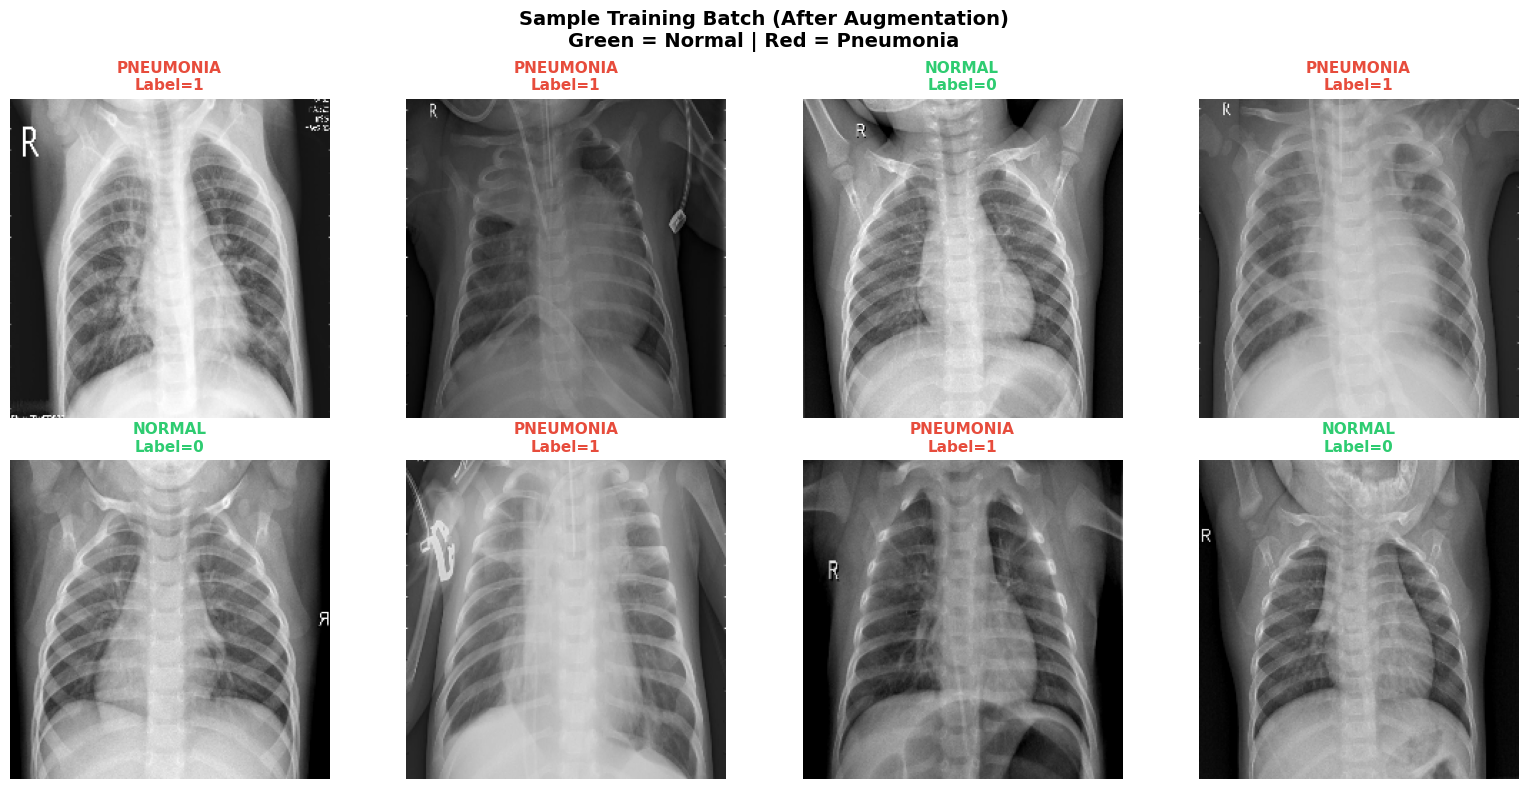

✅ Batch size      : 16
✅ Normal in batch : 4
✅ Pneumonia batch : 12
✅ Image shape     : (224, 224, 3)
✅ Pixel range     : 0.000 - 1.000
✅ Plot saved      : D:/Projects/Harsh_Mini_Project/medical_xray_project/outputs/plots/sample_batch.png
✅ Cell 5 complete


In [6]:
# Cell 5: Visualize a sample batch from training dataset

print("=" * 50)
print("   CELL 5: VISUALIZE SAMPLE BATCH")
print("=" * 50)

# Get one batch from training dataset
for imgs, labels in train_ds.take(1):
    batch_imgs   = imgs.numpy()
    batch_labels = labels.numpy()

# Plot 8 images from the batch
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

label_names = {0: 'NORMAL', 1: 'PNEUMONIA'}
colors      = {0: '#2ecc71', 1: '#e74c3c'}

for i in range(8):
    img       = batch_imgs[i]
    lbl       = batch_labels[i]
    lbl_name  = label_names[lbl]
    color     = colors[lbl]

    axes[i].imshow(img)
    axes[i].set_title(
        f"{lbl_name}\nLabel={lbl}",
        fontsize=11,
        fontweight='bold',
        color=color
    )
    axes[i].axis('off')

    # Colored border
    for spine in axes[i].spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)

plt.suptitle(
    'Sample Training Batch (After Augmentation)\n'
    'Green = Normal | Red = Pneumonia',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()

# Save plot
save_path = f"{PLOTS}/sample_batch.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

# Batch statistics
n_normal  = (batch_labels == 0).sum()
n_pneumo  = (batch_labels == 1).sum()

print(f"✅ Batch size      : {len(batch_labels)}")
print(f"✅ Normal in batch : {n_normal}")
print(f"✅ Pneumonia batch : {n_pneumo}")
print(f"✅ Image shape     : {batch_imgs[0].shape}")
print(f"✅ Pixel range     : "
      f"{batch_imgs.min():.3f} - {batch_imgs.max():.3f}")
print(f"✅ Plot saved      : {save_path}")
print("=" * 50)
print("✅ Cell 5 complete")

In [7]:
# Cell 6: Save preprocessing summary to txt file

print("=" * 50)
print("   CELL 6: SAVING PREPROCESSING SUMMARY")
print("=" * 50)

save_path = f"{RESULTS}/preprocessing_summary.txt"

summary = """
╔══════════════════════════════════════════════════════╗
║         PREPROCESSING SUMMARY - NOTEBOOK 3          ║
╚══════════════════════════════════════════════════════╝

PROJECT : Medical X-ray Anomaly Detection
DATASET : Kaggle Chest X-ray (Pneumonia)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DATASET STATISTICS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Total Images   : 5,840
  NORMAL       : 1,575 (27.0%)
  PNEUMONIA    : 4,265 (73.0%)
Imbalance Ratio: 1 : 2.7

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DATA SPLITS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Train   : 4,087 rows (70%) - 256 batches
Val     :   877 rows (15%) -  55 batches
Test    :   876 rows (15%) -  55 batches
Split   : Stratified (class ratio preserved)
Seed    : 42

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
IMAGE PREPROCESSING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Input Format   : JPEG images (variable sizes)
Output Shape   : (224, 224, 3) float32
Normalization  : Pixel values / 255.0 → [0.0, 1.0]
Decoder        : tf.image.decode_image (JPEG safe)
Batch Size     : 16
Prefetch       : AUTOTUNE

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
AUGMENTATION (Training Only)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. random_flip_left_right  : YES
2. random_brightness       : max_delta = 0.1
3. random_contrast         : lower=0.9, upper=1.1
4. clip_by_value           : range [0.0, 1.0]
5. random_crop             : NO (TF 2.19.0 bug)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SAVED FILES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
plots/class_distribution.png
plots/demographic_distribution.png
plots/sample_xrays.png
plots/sample_batch.png
results/processed_metadata.csv
results/train.csv
results/val.csv
results/test.csv
results/preprocessing_summary.txt
"""

# Save with UTF-8 encoding (CRITICAL for Windows)
with open(save_path, 'w', encoding='utf-8') as f:
    f.write(summary)

# Verify file saved
if os.path.exists(save_path):
    size_kb = os.path.getsize(save_path) / 1024
    print(f"✅ Summary saved  : {save_path}")
    print(f"✅ File size      : {size_kb:.1f} KB")
else:
    print(f"❌ File not saved - check path!")

print()
print("   Plots saved so far:")
plots_list = os.listdir(PLOTS)
for p in sorted(plots_list):
    print(f"   ✅ {p}")

print()
print("   Results saved so far:")
results_list = os.listdir(RESULTS)
for r in sorted(results_list):
    size_kb = os.path.getsize(
                f"{RESULTS}/{r}") / 1024
    print(f"   ✅ {r:<35} {size_kb:.1f} KB")

print("=" * 50)
print("✅ Cell 6 complete")

   CELL 6: SAVING PREPROCESSING SUMMARY
✅ Summary saved  : D:/Projects/Harsh_Mini_Project/medical_xray_project/outputs/results/preprocessing_summary.txt
✅ File size      : 3.2 KB

   Plots saved so far:
   ✅ class_distribution.png
   ✅ demographic_distribution.png
   ✅ sample_batch.png
   ✅ sample_xrays.png

   Results saved so far:
   ✅ preprocessing_summary.txt           3.2 KB
   ✅ processed_metadata.csv              445.8 KB
   ✅ test.csv                            66.5 KB
   ✅ train.csv                           313.7 KB
   ✅ val.csv                             65.7 KB
✅ Cell 6 complete
